In [8]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [21]:
class BMIState(TypedDict):
    WeightKG:float
    HeightM:float
    bmi:float
    category:str


In [22]:
def calculate_bmi(state:BMIState)->BMIState:
    wei=state['WeightKG']
    hei=state['HeightM']
    bmi=wei/(hei**2)
    state['bmi']=bmi
    return state


In [27]:
def label_bmi(state:BMIState)->BMIState:
    bmi=state['bmi']
    if bmi<18.5:
        state['category']="underweight"
    elif 18.5<bmi<25:
             state['category']="normal"
    elif 25<bmi:
             state['category']="obess"

    return state


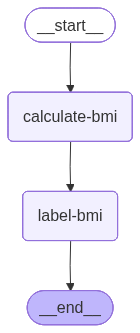

In [28]:
#Define Your graph
graph=StateGraph(BMIState)


#add nodes to graph

graph.add_node('calculate-bmi',calculate_bmi)
graph.add_node('label-bmi',label_bmi)

#add edges to graph

graph.add_edge(START,'calculate-bmi')
graph.add_edge('calculate-bmi','label-bmi')
graph.add_edge('calculate-bmi',END)

#compile the  graph
workflow=graph.compile()
workflow


In [31]:
#execute the graph
final_state=workflow.invoke({'WeightKG':63,'HeightM':1.79})

In [32]:
print(final_state)

{'WeightKG': 63, 'HeightM': 1.79, 'bmi': 19.66230766829999, 'category': 'normal'}
